# Plot the significant networks from corr analysis

- the goal of this script is to identify the networks that were more active for internal or external conditions


In [147]:
# imports
import numpy as np
import os
import re

from nilearn import datasets, plotting
from brainiak.isc import squareform_isfc
from utils_anal import resample_atlas, get_network_labels
from matplotlib import pyplot as plt
from statsmodels.stats.multitest import multipletests
from collections import Counter

import pandas as pd
import seaborn as sns




In [148]:
# paths #
top_dir = '/jukebox/graziano/coolCatIsaac/mei'
data_dir = top_dir + "/data"
work_dir = data_dir + '/work'
behav_dir = top_dir + '/data/work/button_press_counts'
preproc_dir = work_dir + '/preproc'
schaef_dir = '/jukebox/graziano/coolCatIsaac/mei/data/work/schaefer_atlas'
wsfc_dir = work_dir + '/wsfc'

In [149]:
## load 

In [150]:

## load wsfc dictionary
n = 'ext_int_sub_cor_mat.npy'
wsfc_c = np.load(f'{wsfc_dir}/{n}', allow_pickle=True).item()

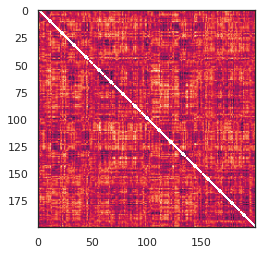

In [151]:
plt.imshow(wsfc_c['sub-003']['external'])

## ROIS

In [152]:
##### Variables for the atlas ### 

num_parc = 200 ## CHANGE ME
num_net= 17 ## CHANGE ME


###### ROI Loading ### 
# LOAD ATLAS #
## fetch dataset
dataset = datasets.fetch_atlas_schaefer_2018(n_rois=num_parc, yeo_networks = num_net)

# get nii dataset location
atlas_filename = dataset.maps
## get *ROI* atlas labels
labels = dataset.labels

# resample loaded atlas 
atlas_nii, atlas_img = resample_atlas(atlas_filename, '')

# Load in network labels for each parcell, parcel UNspecific network labels, and the middle parcel within each network
networks, network_labels, network_idxs = get_network_labels(num_parc, num_net)

count parc:201
shape of atlas nii object (78, 93, 65)
two networks: ['L VisCent', 'L VisPeri'] 
 total nets: 34


# start anal

In [153]:
'''
LOAD:
6vid_wsfc_external_run1-run4.npy
6vid_wsfc_external_run4-run1_fish.npy
6vid_wsfc_internal_run4-run1_fish.npy
6vid_wsfc_run1_ext-int_fish.npy
6vid_wsfc_run1_int-ext_fish.npy
6vid_wsfc_run4_ext-int_fish.npy

6vid_wsfc_run1-4-AV_ext+int_fish.npy
6vid_wsfc_run4_ext-int_fish_TWO_mats.npy
'''

anal_sav_name = '6vid_wsfc_internal_run4-run1_fish.npy'

## get sigs

FDR corrected significant values: 247


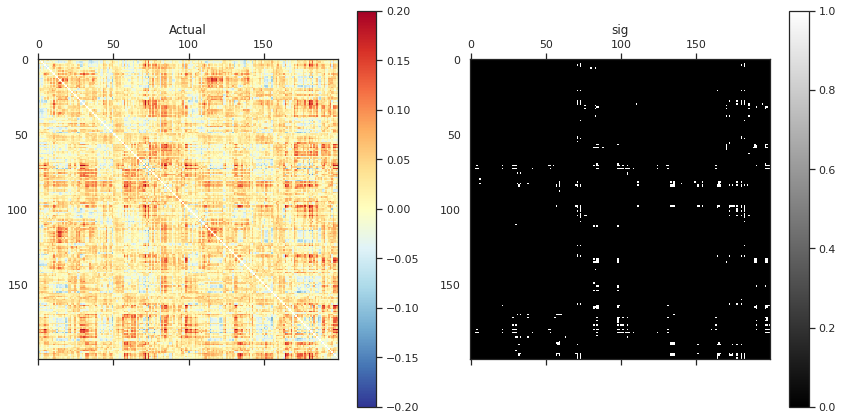

In [154]:
wsfc_info = np.load(os.path.join(wsfc_dir, anal_sav_name), allow_pickle=True).item()
actual_cors_across_movs = wsfc_info['actual_cors_across_movs']
perms_across_movs = wsfc_info['perms_across_movs']
d_shape = 200

## Get significance ##
pval = 0.05

cat_wsfc_av = np.mean(np.stack(actual_cors_across_movs), axis=0)
perm_mat_av = np.mean(np.stack(perms_across_movs), axis=0)

# Two-sided p-values: Compare both lower and upper tails
sig_vals = [
    2 * min(
        (np.sum(val < perm_mat_av[:, idx])) / perm_mat_av.shape[0],
        (np.sum(val > perm_mat_av[:, idx])) / perm_mat_av.shape[0]
    )
    for idx, val in enumerate(cat_wsfc_av)
]

# Transform back into matrix
off_diag = np.array(sig_vals[:-d_shape])
diag = np.array(sig_vals[-d_shape:])
sig_val_mat = squareform_isfc(off_diag, diag)

# Binary significant values
sig_val_bin = [1 if val < pval else 0 for val in sig_vals]

# Run FDR correction
rejected, p_corrected, _, _ = multipletests(off_diag, alpha=0.05, method='fdr_bh')

# Output results
print(f'FDR corrected significant values: {np.sum(rejected)}')

vmin=-.2
vmax=.2
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

## get the averaged actual corr mat ##
off_diag = np.array(cat_wsfc_av[:-d_shape])
diag = np.array(cat_wsfc_av[-d_shape:])
actual_dif_mat = squareform_isfc(off_diag, diag)

image1 = axs[0].matshow(actual_dif_mat, vmin=vmin, vmax=vmax, cmap='RdYlBu_r')
axs[0].set_title(f'Actual')
cbar1 = plt.colorbar(image1, ax=axs[0])


# Get the significant values from calculation above #
off_diag = np.array(sig_val_bin) # **** ONE SAMPLE T
off_diag = np.array(rejected * 1) # **** ONE SAMPLE T
diag = np.zeros((d_shape))
sig_mat_r = squareform_isfc(off_diag, diag)
image2 = axs[1].matshow(sig_mat_r, cmap='binary_r')
axs[1].set_title('sig')
cbar1 = plt.colorbar(image2, ax=axs[1])

# Adjust spacing between subplots and colorbars
plt.tight_layout()
plt.show()


# print the significant corrs

In [94]:
## either internal or external

In [9]:
# Assuming sig_mat_r is your 200x200 matrix
row_indices, col_indices = np.where(sig_mat_r == 1)

# Combine row and column indices into a list of tuples
indices = list(zip(row_indices, col_indices))

# Eliminate duplicates by keeping only pairs where row < column
unique_indices = [(r, c) for r, c in indices if r < c]

# Print the result
print("Unique Row, Column Indices of 1s:")
network_pairs = []
pos_neg = []
pos = []
neg = []

for idx in unique_indices:
    #print(f'{networks[idx[0]]} AND {networks[idx[1]]}' )
    network_pairs.append(f'{networks[idx[0]]} AND {networks[idx[1]]}')
    pos_neg.append(1 if actual_dif_mat[idx] > 0 else -1)
    if actual_dif_mat[idx] > 0: print(f'{networks[idx[0]]} AND {networks[idx[1]]}') # CHANGE MEE 
    pair_ = f'{networks[idx[0]]} AND {networks[idx[1]]}'
    pos.append(pair_) if actual_dif_mat[idx] > 0 else neg.append(pair_)


Unique Row, Column Indices of 1s:
L VisCent AND L ContC
L VisCent AND R ContC
L VisCent AND L ContC
L VisCent AND L ContC
L VisCent AND R ContC
L VisCent AND R ContC
L VisCent AND L ContC
L VisCent AND R ContC
L VisPeri AND L DefaultA
L VisPeri AND L DefaultB
L SomMotB AND L ContC
L SomMotB AND L ContC
L SomMotB AND R ContA
L SomMotB AND R ContC
L SomMotB AND R ContC
L DorsAttnA AND L ContC
L DorsAttnA AND L ContC
L DorsAttnA AND R ContB
L DorsAttnA AND R ContB
L DorsAttnA AND R ContC
L DorsAttnA AND R ContC
L DorsAttnA AND L ContC
L DorsAttnA AND L ContC
L DorsAttnA AND R ContC
L DorsAttnA AND R ContC
L DorsAttnA AND L ContC
L DorsAttnA AND L ContC
L DorsAttnA AND R VisPeri
L DorsAttnA AND R ContB
L DorsAttnA AND R ContC
L DorsAttnA AND R ContC
L DorsAttnA AND R DefaultA
L DorsAttnA AND R DefaultC
L DorsAttnA AND L DefaultA
L DorsAttnA AND L DefaultB
L DorsAttnA AND R ContB
L DorsAttnA AND R DefaultA
L DorsAttnA AND L DefaultB
L DorsAttnA AND L DefaultB
L DorsAttnA AND R DefaultB
L Do

In [10]:
print(f'NUM POS: {np.sum(np.where(np.array(pos_neg)==1, 1,0))}\n'
      f'NUM NEG: {np.sum(np.where(np.array(pos_neg)==-1, 1,0))}')

NUM POS: 245
NUM NEG: 2


In [12]:
###### CHANGE ME ########
a = 'positive' ### positive or negative

network_pairs = pos if a == 'positive' else neg    

# Use Counter to count occurrences of each pair
pair_counts = Counter(network_pairs)

# Convert the counter to a pandas DataFrame
df = pd.DataFrame(pair_counts.items(), columns=['Pair', 'Count'])

# Sort the DataFrame by the count (optional)
df = df.sort_values(by='Count', ascending=False).reset_index(drop=True)

# Display the result
df

,Pair,Count
0,L DefaultB AND R DorsAttnA,9
1,L DefaultB AND R ContA,9
2,L ContC AND R TempPar,8
3,R ContB AND R TempPar,8
4,R ContC AND R TempPar,8
...,...,...
71,L TempPar AND R VisPeri,1
72,L DefaultB AND R DefaultA,1
73,L DefaultB AND R DorsAttnB,1
74,L VisPeri AND L DefaultB,1


In [108]:
final_df

,Pair,Count,Connectivity_Type
0,L DefaultB AND R DorsAttnA,9,internal
1,L DefaultB AND R ContA,9,internal
2,L ContC AND R TempPar,8,internal
3,R ContB AND R TempPar,8,internal
4,R ContC AND R TempPar,8,internal
...,...,...,...
168,L SomMotA AND R LimbicA,1,external
169,L SomMotA AND R SomMotB,1,external
170,L DefaultA AND R ContA,1,external
173,L DefaultC AND R DorsAttnB,1,external


# Extract significant correlations for internal and external

- In the below cells we extract correlations from targeted networks (that were significant)

In [101]:
## find all significant correlations indices
row_indices, col_indices = np.where(sig_mat_r == 1)
indices_sig = list(zip(row_indices, col_indices))

In [102]:
c_dic = {}

for c in ['internal', 'external']:
    # store networks for each condition
    sig_net_idxs = {}

    # Iterate through each pair
    for _, row_net in df.iterrows():
        net1, net2 = row_net['Pair'].split(' AND ')

        # Convert to format: LH_ or RH_ depending on L or R prefix
        def format_net(net):
            hemi, name = net.split(' ', 1)
            return f"{'LH' if hemi == 'L' else 'RH'}_{name}".encode()

        substr_1 = format_net(net1)
        substr_2 = format_net(net2)

        # Assuming `labels` is defined elsewhere in your code
        indices_1 = [i for i, x in enumerate(labels) if substr_1 in x]
        indices_2 = [i for i, x in enumerate(labels) if substr_2 in x]

        print(f"Pair: {row_net['Pair']}")
        print(f"Indices for {substr_1}:", indices_1)
        print(f"Indices for {substr_2}:", indices_2)



        # Initialize results dictionary to store connectivity across subjects for this network
        acrs_s_con = []

        # Iterate over subjects (assuming `wsfc_c` is a dictionary with subjects as keys)
        for s in wsfc_c:
            #print(f'processing {s}...')
            # Check if the connectivity data is available for the given condition
            try:
                s_mat = wsfc_c[s][c]  # has connectivity data
            except KeyError:
                print(f"KeyError: {s} or {c.capitalize()} not found in conn or bpress")
                continue

            # Extract the connectivity matrix for the subject
            extracted_values = []
            for row in indices_1:
                for col in indices_2:
                    if (row, col) in indices_sig:
                        extracted_values.append(s_mat[row, col])

            # Average the extracted values
            if extracted_values:  # Ensure there are extracted values
                acrs_s_con.append(np.mean(extracted_values))  # Only append the first value -- wtf does this mean (nice pun)

        sig_net_idxs[row_net['Pair']] = np.mean(acrs_s_con) ## store the mean across subjects
        print("----------")
    c_dic[c] = sig_net_idxs



Pair: L DefaultB AND R DorsAttnA
Indices for b'LH_DefaultB': [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Indices for b'RH_DorsAttnA': [130, 131, 132, 133, 134, 135]
KeyError: sub-020 or Internal not found in conn or bpress


/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


----------
Pair: L DefaultB AND R ContA
Indices for b'LH_DefaultB': [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Indices for b'RH_ContA': [164, 165, 166, 167, 168, 169]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L ContC AND R TempPar
Indices for b'LH_ContC': [71, 72, 73]
Indices for b'RH_TempPar': [196, 197, 198, 199]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: R ContB AND R TempPar
Indices for b'RH_ContB': [170, 171, 172, 173, 174, 175, 176, 177, 178, 179]
Indices for b'RH_TempPar': [196, 197, 198, 199]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: R ContC AND R TempPar
Indices for b'RH_ContC': [180, 181, 182]
Indices for b'RH_TempPar': [196, 197, 198, 199]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L ContA AND L DefaultB
Indices for b'LH_ContA': [56, 57, 58, 59, 60, 61, 62, 63, 64, 65]
Indices for b'LH_DefaultB': [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 

KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L DefaultA AND R VisCent
Indices for b'LH_DefaultA': [74, 75, 76, 77, 78, 79, 80, 81]
Indices for b'RH_VisCent': [100, 101, 102, 103, 104, 105]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L DefaultB AND R VisPeri
Indices for b'LH_DefaultB': [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Indices for b'RH_VisPeri': [106, 107, 108, 109, 110, 111]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L SomMotB AND R ContC
Indices for b'LH_SomMotB': [20, 21, 22, 23, 24, 25, 26, 27]
Indices for b'RH_ContC': [180, 181, 182]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L SomMotB AND L ContC
Indices for b'LH_SomMotB': [20, 21, 22, 23, 24, 25, 26, 27]
Indices for b'LH_ContC': [71, 72, 73]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L DorsAttnB AND R ContB
Indices for b'LH_DorsAttnB': [34, 35, 36, 37, 38]


----------
Pair: R SomMotB AND R ContB
Indices for b'RH_SomMotB': [123, 124, 125, 126, 127, 128, 129]
Indices for b'RH_ContB': [170, 171, 172, 173, 174, 175, 176, 177, 178, 179]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L DefaultA AND R DorsAttnB
Indices for b'LH_DefaultA': [74, 75, 76, 77, 78, 79, 80, 81]
Indices for b'RH_DorsAttnB': [136, 137, 138, 139, 140]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L LimbicA AND R DefaultA
Indices for b'LH_LimbicA': [52, 53, 54, 55]
Indices for b'RH_DefaultA': [183, 184, 185, 186, 187, 188]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L ContC AND R DorsAttnB
Indices for b'LH_ContC': [71, 72, 73]
Indices for b'RH_DorsAttnB': [136, 137, 138, 139, 140]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L VisCent AND R SalVentAttnB
Indices for b'LH_VisCent': [0, 1, 2, 3, 4, 5]
Indices for b'RH_SalVentAttnB': [150, 151, 152, 153, 154, 1

----------
Pair: L DorsAttnA AND L DefaultC
Indices for b'LH_DorsAttnA': [28, 29, 30, 31, 32, 33]
Indices for b'LH_DefaultC': [95, 96, 97]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L ContC AND R SalVentAttnA
Indices for b'LH_ContC': [71, 72, 73]
Indices for b'RH_SalVentAttnA': [141, 142, 143, 144, 145, 146, 147, 148, 149]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L ContC AND R DefaultC
Indices for b'LH_ContC': [71, 72, 73]
Indices for b'RH_DefaultC': [193, 194, 195]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L SomMotB AND R SalVentAttnB
Indices for b'LH_SomMotB': [20, 21, 22, 23, 24, 25, 26, 27]
Indices for b'RH_SalVentAttnB': [150, 151, 152, 153, 154, 155]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L SomMotB AND L DefaultA
Indices for b'LH_SomMotB': [20, 21, 22, 23, 24, 25, 26, 27]
Indices for b'LH_DefaultA': [74, 75, 76, 77, 78, 79, 80, 81]
KeyError: sub-0

KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L LimbicA AND R ContC
Indices for b'LH_LimbicA': [52, 53, 54, 55]
Indices for b'RH_ContC': [180, 181, 182]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L DorsAttnA AND R TempPar
Indices for b'LH_DorsAttnA': [28, 29, 30, 31, 32, 33]
Indices for b'RH_TempPar': [196, 197, 198, 199]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L ContC AND R DorsAttnA
Indices for b'LH_ContC': [71, 72, 73]
Indices for b'RH_DorsAttnA': [130, 131, 132, 133, 134, 135]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L TempPar AND R ContA
Indices for b'LH_TempPar': [98, 99]
Indices for b'RH_ContA': [164, 165, 166, 167, 168, 169]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L TempPar AND R SalVentAttnB
Indices for b'LH_TempPar': [98, 99]
Indices for b'RH_SalVentAttnB': [150, 151, 152, 153, 154, 155]
KeyError: sub-020 or Exter

----------
Pair: L TempPar AND R VisPeri
Indices for b'LH_TempPar': [98, 99]
Indices for b'RH_VisPeri': [106, 107, 108, 109, 110, 111]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L DefaultB AND R DefaultA
Indices for b'LH_DefaultB': [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Indices for b'RH_DefaultA': [183, 184, 185, 186, 187, 188]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L DefaultB AND R DorsAttnB
Indices for b'LH_DefaultB': [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Indices for b'RH_DorsAttnB': [136, 137, 138, 139, 140]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L VisPeri AND L DefaultB
Indices for b'LH_VisPeri': [6, 7, 8, 9, 10, 11]
Indices for b'LH_DefaultB': [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L SomMotB AND R ContA
Indices for b'LH_SomMotB': [20, 21, 22, 23, 24, 25, 26, 27]


----------
Pair: R SalVentAttnA AND R ContC
Indices for b'RH_SalVentAttnA': [141, 142, 143, 144, 145, 146, 147, 148, 149]
Indices for b'RH_ContC': [180, 181, 182]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L LimbicA AND R ContA
Indices for b'LH_LimbicA': [52, 53, 54, 55]
Indices for b'RH_ContA': [164, 165, 166, 167, 168, 169]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L SomMotB AND R ContB
Indices for b'LH_SomMotB': [20, 21, 22, 23, 24, 25, 26, 27]
Indices for b'RH_ContB': [170, 171, 172, 173, 174, 175, 176, 177, 178, 179]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L SalVentAttnB AND L TempPar
Indices for b'LH_SalVentAttnB': [46, 47, 48, 49]
Indices for b'LH_TempPar': [98, 99]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L SalVentAttnB AND R LimbicA
Indices for b'LH_SalVentAttnB': [46, 47, 48, 49]
Indices for b'RH_LimbicA': [160, 161, 162, 163]
KeyError: sub-020

In [103]:
# Convert to DataFrame
df = pd.DataFrame({
    'network': list(c_dic['external'].keys()),
    'external': list(c_dic['external'].values()),
    'internal': [c_dic['internal'][k] for k in c_dic['external'].keys()]
})

df = pd.DataFrame({
    'network': list(c_dic['external'].keys()),
    'external': list(c_dic['external'].values()),
    'internal': [c_dic['internal'][k] for k in c_dic['external'].keys()]
})


df.head()

,network,external,internal
0,L DefaultB AND R DorsAttnA,NaN,NaN
1,L DefaultB AND R ContA,NaN,NaN
2,L ContC AND R TempPar,0.095038,0.164686
3,R ContB AND R TempPar,0.091064,0.134818
4,R ContC AND R TempPar,0.099389,0.171453


### Step 1: Define a function to get data network data regardless of hemisphere

In [104]:
def get_abstract_pair(pair):
    net1, net2 = pair.split(' AND ')
    net1 = net1.strip()[2:]  # Remove 'L ' or 'R '
    net2 = net2.strip()[2:]
    return ' AND '.join(sorted([net1, net2]))

# Step 2: Create abstract label column
df['across_hemi'] = df['network'].apply(get_abstract_pair)

# Step 3: Group by abstracted label and compute mean for internal & external
grouped_df = df.groupby('across_hemi')[['external', 'internal']].mean().reset_index()

# Step 4: Rename columns to make them explicit
grouped_df = grouped_df.rename(columns={
    'abstract_pair': 'network_ab',
    'external': 'external_ab',
    'internal': 'internal_ab'
})

df.head()


,network,external,internal,across_hemi
0,L DefaultB AND R DorsAttnA,NaN,NaN,DefaultB AND DorsAttnA
1,L DefaultB AND R ContA,NaN,NaN,ContA AND DefaultB
2,L ContC AND R TempPar,0.095038,0.164686,ContC AND TempPar
3,R ContB AND R TempPar,0.091064,0.134818,ContB AND TempPar
4,R ContC AND R TempPar,0.099389,0.171453,ContC AND TempPar


### # Step 2: Define a function to strip hemisphere and specific network label (e.g DefaultB)


In [105]:
def get_super_abstract_pair(pair):
    net1, net2 = pair.split(' AND ')
    
    # Strip hemisphere (first 2 characters) and trailing capital letter (e.g., 'A', 'B')
    def simplify(net):
        net = net.strip()[2:]  # remove 'L ' or 'R '
        return re.sub(r'[A-Z]$', '', net)  # remove trailing capital letter

    net1_simple = simplify(net1)
    net2_simple = simplify(net2)
    
    return ' AND '.join(sorted([net1_simple, net2_simple]))

# Step 2: Apply it to the DataFrame
df['across_hemi_and_type'] = df['network'].apply(get_super_abstract_pair)

# Optional preview
df.head()


,network,external,internal,across_hemi,across_hemi_and_type
0,L DefaultB AND R DorsAttnA,NaN,NaN,DefaultB AND DorsAttnA,Default AND DorsAttn
1,L DefaultB AND R ContA,NaN,NaN,ContA AND DefaultB,Cont AND Default
2,L ContC AND R TempPar,0.095038,0.164686,ContC AND TempPar,Cont AND TempPar
3,R ContB AND R TempPar,0.091064,0.134818,ContB AND TempPar,Cont AND TempPar
4,R ContC AND R TempPar,0.099389,0.171453,ContC AND TempPar,Cont AND TempPar


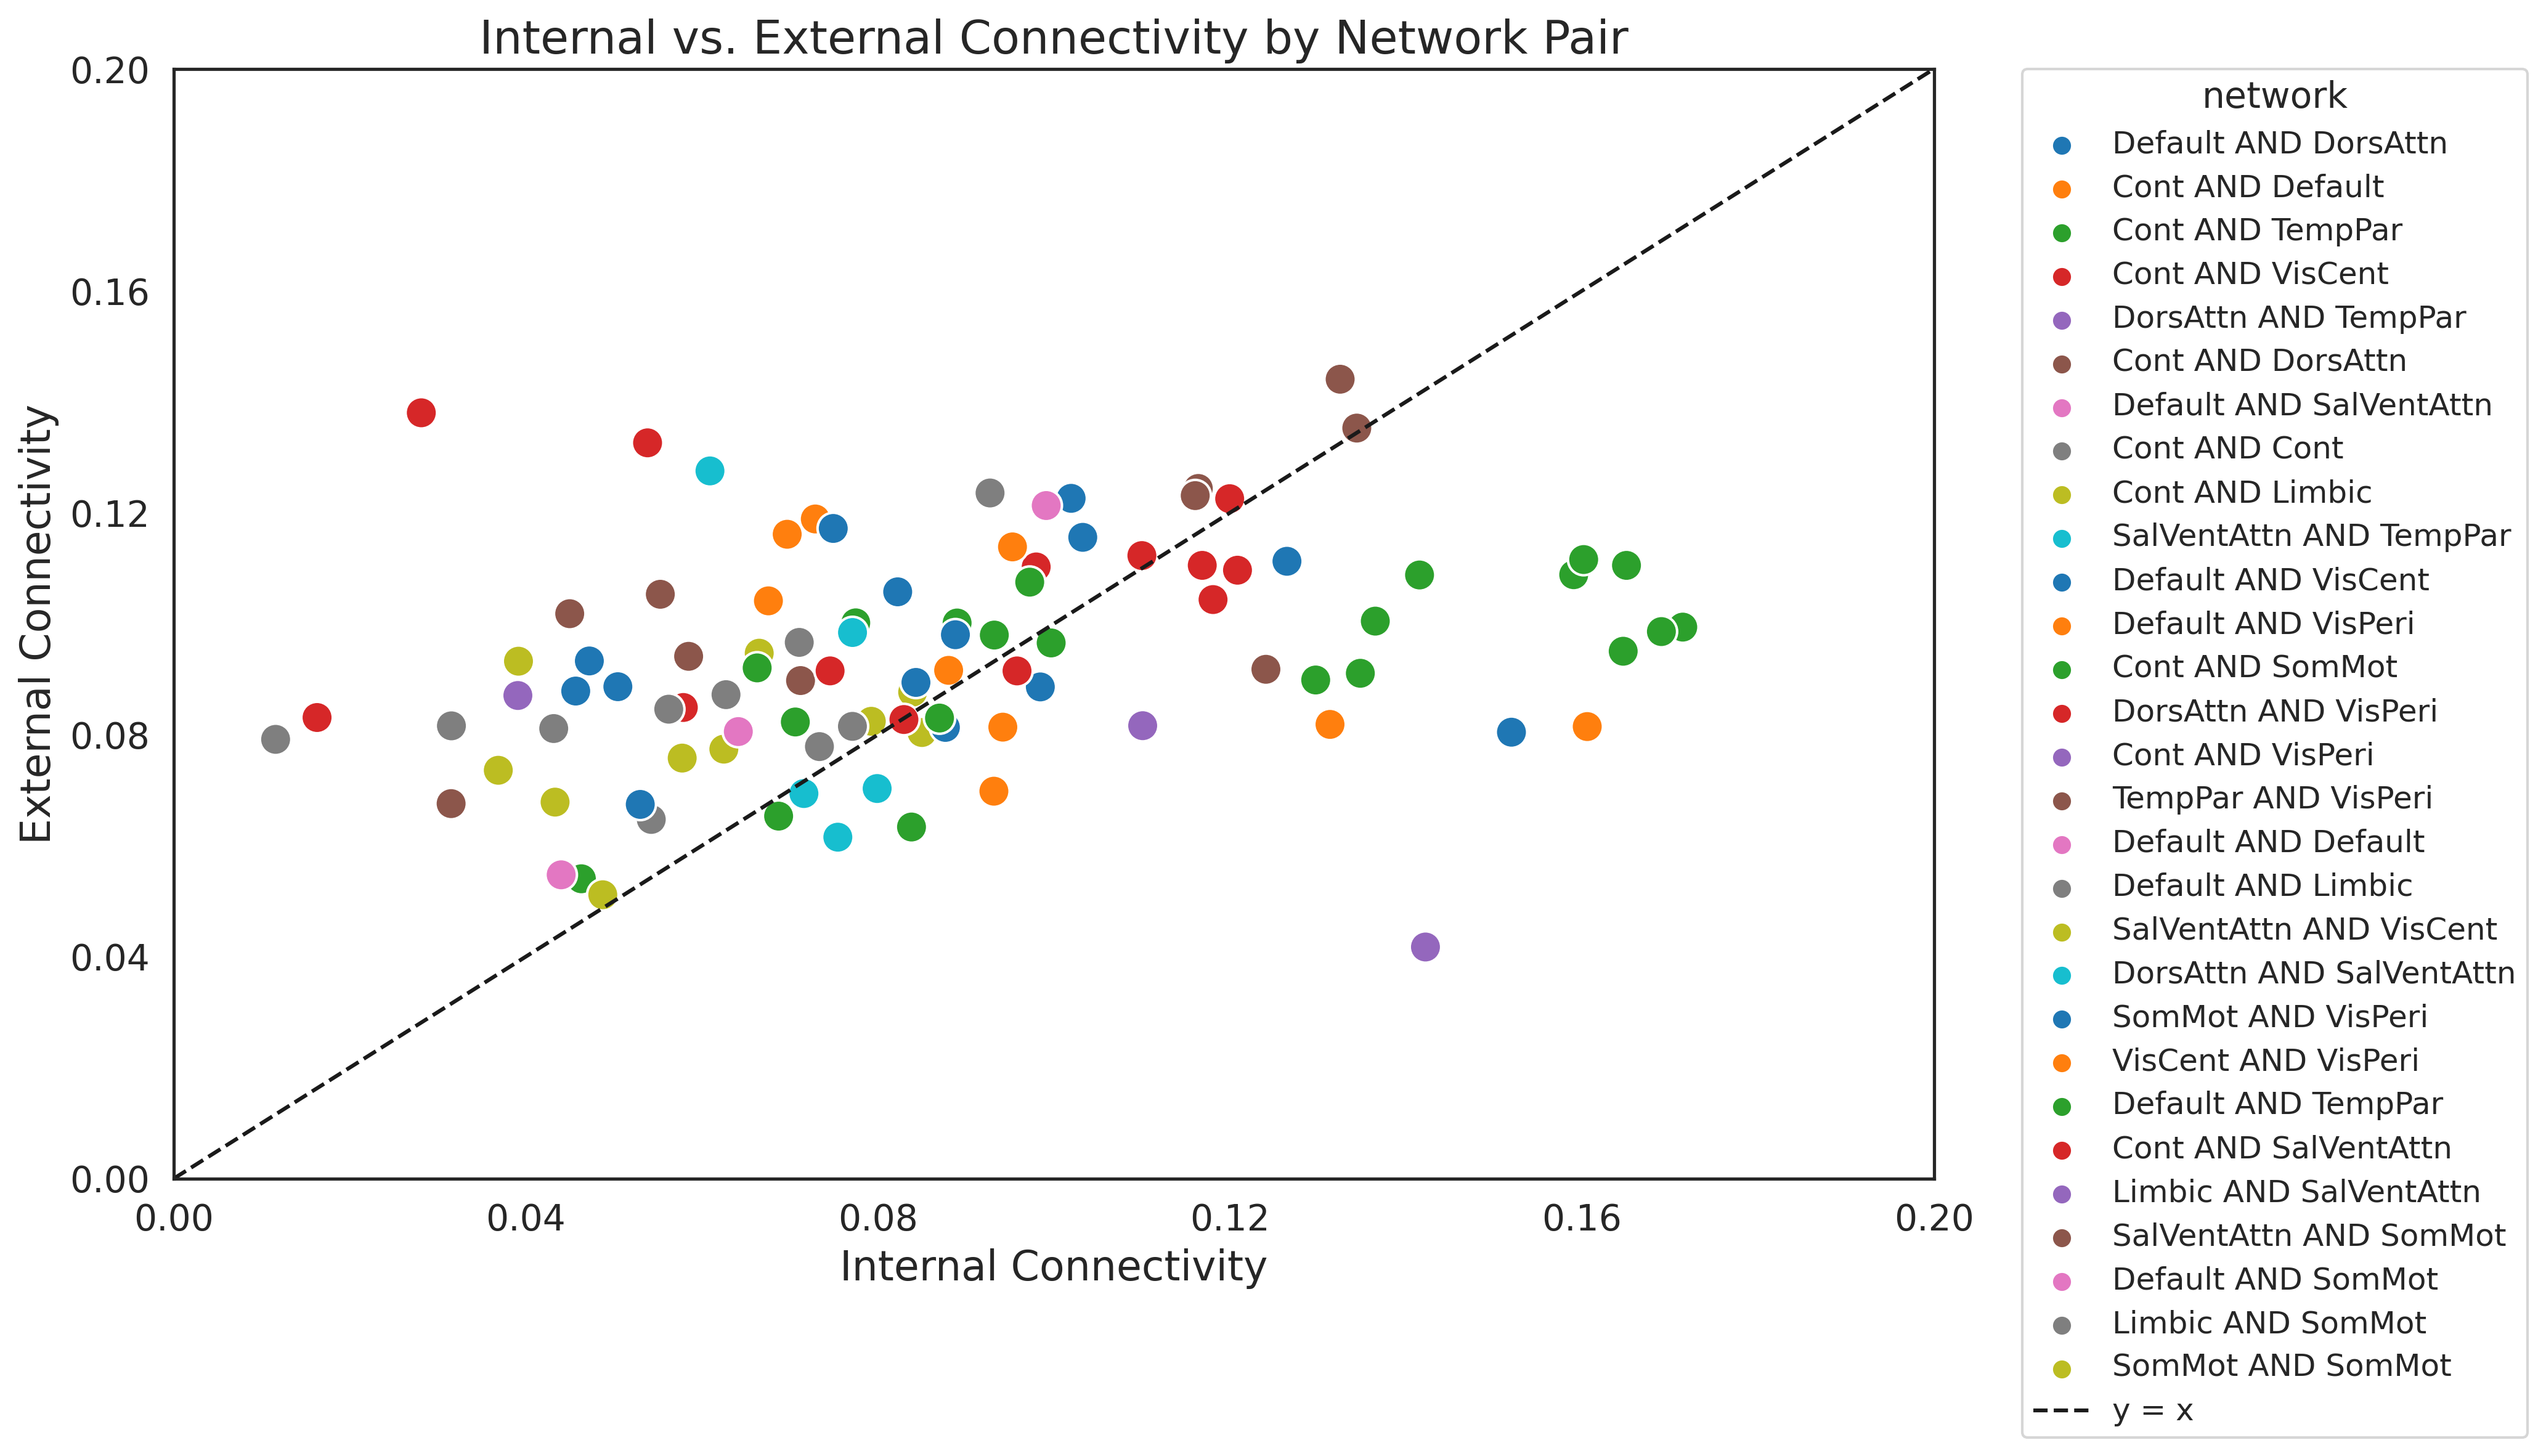

In [107]:
# Create a larger figure
plt.figure(figsize=(14, 8), dpi=300)

# Create scatterplot with larger points
scatter = sns.scatterplot(
    data=df,
    x='internal',
    y='external',
    hue='across_hemi_and_type',
    palette='tab10',
    s=150  # Point size increased
)

# Set font sizes
plt.xlabel("Internal Connectivity", fontsize=16)
plt.ylabel("External Connectivity", fontsize=16)
plt.title("Internal vs. External Connectivity by Network Pair", fontsize=18)

# Resize tick labels
scatter.tick_params(axis='both', labelsize=14)

# Calculate the maximum value between the x and y axis
max_value = max(df['internal'].max(), df['external'].max())

# Define limits ensuring both x and y axes share the same max
#lims = [0.0, max_value]
lims = [0.0, .2]

# Set x and y limits to match for identity line
plt.xlim(lims)
plt.ylim(lims)

# Add identity line
plt.plot(lims, lims, 'k--', linewidth=1.5, label='y = x')

# Manually set the ticks for both axes based on the range
step = 0.04  # You can adjust the step size if needed (e.g., 1, 0.5, etc.)
ticks = np.arange(lims[0], lims[1] + step, step)  # Use np.arange for float steps

# Set x and y ticks to match for both axes
plt.gca().set_xticks(ticks)
plt.gca().set_yticks(ticks)

# Resize and move legend
legend = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
legend.set_title("network", prop={'size': 14})
for text in legend.get_texts():
    text.set_fontsize(12)

# Ensure no padding around the plot
plt.tight_layout()

plt.show()


# Get positive SIGNIFICANT values for external AND External TOGETHER

In [155]:
dfs = []
sig_mat_r_2 = []

for c in ['internal', 'external']:
    anal_sav_name = f'6vid_wsfc_{c}_run4-run1_fish.npy'

    wsfc_info = np.load(os.path.join(wsfc_dir, anal_sav_name), allow_pickle=True).item()
    actual_cors_across_movs = wsfc_info['actual_cors_across_movs']
    perms_across_movs = wsfc_info['perms_across_movs']
    d_shape = 200

    ## Get significance ##
    pval = 0.05

    cat_wsfc_av = np.mean(np.stack(actual_cors_across_movs), axis=0)
    perm_mat_av = np.mean(np.stack(perms_across_movs), axis=0)

    # Two-sided p-values: Compare both lower and upper tails
    sig_vals = [
        2 * min(
            (np.sum(val < perm_mat_av[:, idx])) / perm_mat_av.shape[0],
            (np.sum(val > perm_mat_av[:, idx])) / perm_mat_av.shape[0]
        )
        for idx, val in enumerate(cat_wsfc_av)
    ]

    # Transform back into matrix
    off_diag = np.array(sig_vals[:-d_shape])
    diag = np.array(sig_vals[-d_shape:])
    sig_val_mat = squareform_isfc(off_diag, diag)

    # Binary significant values
    sig_val_bin = [1 if val < pval else 0 for val in sig_vals]

    # Run FDR correction
    rejected, p_corrected, _, _ = multipletests(off_diag, alpha=0.05, method='fdr_bh')

    # Output results
    print(f'FDR corrected significant values: {np.sum(rejected)}')

    ## get the averaged actual corr mat ##
    off_diag = np.array(cat_wsfc_av[:-d_shape])
    diag = np.array(cat_wsfc_av[-d_shape:])
    actual_dif_mat = squareform_isfc(off_diag, diag)


    # Get the significant values from calculation above #
    off_diag = np.array(sig_val_bin) # **** ONE SAMPLE T
    off_diag = np.array(rejected * 1) # **** ONE SAMPLE T
    diag = np.zeros((d_shape))
    sig_mat_r = squareform_isfc(off_diag, diag)


    ##############################

    # Assuming sig_mat_r is your 200x200 matrix
    row_indices, col_indices = np.where(sig_mat_r == 1)

    # Combine row and column indices into a list of tuples
    indices = list(zip(row_indices, col_indices))

    # Eliminate duplicates by keeping only pairs where row < column
    unique_indices = [(r, c) for r, c in indices if r < c]

    # Print the result
    print("Unique Row, Column Indices of 1s:")
    network_pairs = []
    pos_neg = []
    pos = []
    neg = []

    for idx in unique_indices:
        #print(f'{networks[idx[0]]} AND {networks[idx[1]]}' )
        network_pairs.append(f'{networks[idx[0]]} AND {networks[idx[1]]}')
        pos_neg.append(1 if actual_dif_mat[idx] > 0 else -1)
        if actual_dif_mat[idx] > 0: print(f'{networks[idx[0]]} AND {networks[idx[1]]}') # CHANGE MEE 
        pair_ = f'{networks[idx[0]]} AND {networks[idx[1]]}'
        pos.append(pair_) if actual_dif_mat[idx] > 0 else neg.append(pair_)

    ###### CHANGE ME ########
    a = 'positive' ### positive or negative sig cors

    network_pairs = pos if a == 'positive' else neg    

    # Use Counter to count occurrences of each pair
    pair_counts = Counter(network_pairs)

    # Convert the counter to a pandas DataFrame
    df = pd.DataFrame(pair_counts.items(), columns=['Pair', 'Count'])

    # Sort the DataFrame by the count (optional)
    df = df.sort_values(by='Count', ascending=False).reset_index(drop=True)

    # Add a new column to indicate the connectivity type (internal or external)
    df['Connectivity_Type'] = c

    # Append the dataframe to the list
    dfs.append(df)
    sig_mat_r_2.append(sig_mat_r)

# Concatenate all dataframes into a single dataframe
final_df = pd.concat(dfs, ignore_index=True)

# concatenate the *significant* correlation matrices to find all cells that were significant in either condition
sig_mat_r = np.sum(sig_mat_r_2, axis=0)

# Eliminate duplicates based on the 'Pair' column
final_df = final_df.drop_duplicates(subset=['Pair'])



FDR corrected significant values: 247
Unique Row, Column Indices of 1s:
L VisCent AND L ContC
L VisCent AND R ContC
L VisCent AND L ContC
L VisCent AND L ContC
L VisCent AND R ContC
L VisCent AND R ContC
L VisCent AND L ContC
L VisCent AND R ContC
L VisPeri AND L DefaultA
L VisPeri AND L DefaultB
L SomMotB AND L ContC
L SomMotB AND L ContC
L SomMotB AND R ContA
L SomMotB AND R ContC
L SomMotB AND R ContC
L DorsAttnA AND L ContC
L DorsAttnA AND L ContC
L DorsAttnA AND R ContB
L DorsAttnA AND R ContB
L DorsAttnA AND R ContC
L DorsAttnA AND R ContC
L DorsAttnA AND L ContC
L DorsAttnA AND L ContC
L DorsAttnA AND R ContC
L DorsAttnA AND R ContC
L DorsAttnA AND L ContC
L DorsAttnA AND L ContC
L DorsAttnA AND R VisPeri
L DorsAttnA AND R ContB
L DorsAttnA AND R ContC
L DorsAttnA AND R ContC
L DorsAttnA AND R DefaultA
L DorsAttnA AND R DefaultC
L DorsAttnA AND L DefaultA
L DorsAttnA AND L DefaultB
L DorsAttnA AND R ContB
L DorsAttnA AND R DefaultA
L DorsAttnA AND L DefaultB
L DorsAttnA AND L De

# Extract significant correlations for internal and external TOGETHER

- In the below cells we extract correlations from targeted networks (that were significant) for both internal and external condtions

In [156]:
np.unique(sig_mat_r)

array([0, 1, 2])

In [157]:
## find all significant correlations indices
row_indices, col_indices = np.where(sig_mat_r >= 1) ## **SIGNIFICANT CONS IN EITHER THE INTERNAL OR EXTERNAL CASE ! 
indices_sig = list(zip(row_indices, col_indices))

df = final_df ## df with the MERGED sig SUBNETWORKS, not connections

In [158]:
c_dic = {}

# FOR each oncdition, FOR each subnetwork, find alL sig connections ACROSS EITHER  conds, then average
# alternatively, 
for c in ['internal', 'external']: 
    # store networks for each condition
    sig_net_idxs = {}

    # Iterate through each SUB-NETWORK pair
    for _, row_net in df.iterrows():
        net1, net2 = row_net['Pair'].split(' AND ')

        # Convert to format: LH_ or RH_ depending on L or R prefix
        def format_net(net):
            hemi, name = net.split(' ', 1)
            return f"{'LH' if hemi == 'L' else 'RH'}_{name}".encode()

        substr_1 = format_net(net1)
        substr_2 = format_net(net2)

        # Assuming `labels` is defined elsewhere in your code
        indices_1 = [i for i, x in enumerate(labels) if substr_1 in x]
        indices_2 = [i for i, x in enumerate(labels) if substr_2 in x]

        print(f"Pair: {row_net['Pair']}")
        print(f"Indices for {substr_1}:", indices_1)
        print(f"Indices for {substr_2}:", indices_2)



        # Initialize results dictionary to store connectivity across subjects for this network
        acrs_s_con = []

        # Iterate over subjects (assuming `wsfc_c` is a dictionary with subjects as keys)
        for s in wsfc_c:
            #print(f'processing {s}...')
            # Check if the connectivity data is available for the given condition
            try:
                s_mat = wsfc_c[s][c]  # has connectivity data
            except KeyError:
                print(f"KeyError: {s} or {c.capitalize()} not found in conn or bpress")
                continue

            # Extract the connectivity matrix for the subject
            extracted_values = []
            for row in indices_1:
                for col in indices_2:
                    if (row, col) in indices_sig:
                        extracted_values.append(s_mat[row, col])

            # Average the extracted values of the connections WITHIN each subnetwork pair
            # compared to previous script, more indices may be included because we're finding idxs that 
            # were significant for BOTH internal and external...
            if extracted_values:  # Ensure there are extracted values
                acrs_s_con.append(np.mean(extracted_values))  # Only append the first value -- wtf does this mean (nice pun)

        sig_net_idxs[row_net['Pair']] = np.mean(acrs_s_con) ## store the mean across subjects
        print("----------")
    c_dic[c] = sig_net_idxs



Pair: L DefaultB AND R DorsAttnA
Indices for b'LH_DefaultB': [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Indices for b'RH_DorsAttnA': [130, 131, 132, 133, 134, 135]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L DefaultB AND R ContA
Indices for b'LH_DefaultB': [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Indices for b'RH_ContA': [164, 165, 166, 167, 168, 169]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L ContC AND R TempPar
Indices for b'LH_ContC': [71, 72, 73]
Indices for b'RH_TempPar': [196, 197, 198, 199]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: R ContB AND R TempPar
Indices for b'RH_ContB': [170, 171, 172, 173, 174, 175, 176, 177, 178, 179]
Indices for b'RH_TempPar': [196, 197, 198, 199]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: R ContC AND R TempPar
Indices for b'RH_ContC': [180, 181, 182]
Indices for b'RH_TempPar': [196, 197, 198, 199]
K

----------
Pair: R ContB AND R DefaultB
Indices for b'RH_ContB': [170, 171, 172, 173, 174, 175, 176, 177, 178, 179]
Indices for b'RH_DefaultB': [189, 190, 191, 192]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L DefaultA AND R VisCent
Indices for b'LH_DefaultA': [74, 75, 76, 77, 78, 79, 80, 81]
Indices for b'RH_VisCent': [100, 101, 102, 103, 104, 105]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L DefaultB AND R VisPeri
Indices for b'LH_DefaultB': [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Indices for b'RH_VisPeri': [106, 107, 108, 109, 110, 111]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L SomMotB AND R ContC
Indices for b'LH_SomMotB': [20, 21, 22, 23, 24, 25, 26, 27]
Indices for b'RH_ContC': [180, 181, 182]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L SomMotB AND L ContC
Indices for b'LH_SomMotB': [20, 21, 22, 23, 24, 25, 26, 27]
Indices for b'LH_ContC

KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L DefaultA AND R LimbicA
Indices for b'LH_DefaultA': [74, 75, 76, 77, 78, 79, 80, 81]
Indices for b'RH_LimbicA': [160, 161, 162, 163]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: R SomMotB AND R ContB
Indices for b'RH_SomMotB': [123, 124, 125, 126, 127, 128, 129]
Indices for b'RH_ContB': [170, 171, 172, 173, 174, 175, 176, 177, 178, 179]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L DefaultA AND R DorsAttnB
Indices for b'LH_DefaultA': [74, 75, 76, 77, 78, 79, 80, 81]
Indices for b'RH_DorsAttnB': [136, 137, 138, 139, 140]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L LimbicA AND R DefaultA
Indices for b'LH_LimbicA': [52, 53, 54, 55]
Indices for b'RH_DefaultA': [183, 184, 185, 186, 187, 188]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L ContC AND R DorsAttnB
Indices for b'LH_ContC': [71, 72, 7

----------
Pair: L DorsAttnA AND R SalVentAttnA
Indices for b'LH_DorsAttnA': [28, 29, 30, 31, 32, 33]
Indices for b'RH_SalVentAttnA': [141, 142, 143, 144, 145, 146, 147, 148, 149]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L DorsAttnA AND L DefaultC
Indices for b'LH_DorsAttnA': [28, 29, 30, 31, 32, 33]
Indices for b'LH_DefaultC': [95, 96, 97]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L ContC AND R SalVentAttnA
Indices for b'LH_ContC': [71, 72, 73]
Indices for b'RH_SalVentAttnA': [141, 142, 143, 144, 145, 146, 147, 148, 149]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L ContC AND R DefaultC
Indices for b'LH_ContC': [71, 72, 73]
Indices for b'RH_DefaultC': [193, 194, 195]
KeyError: sub-020 or Internal not found in conn or bpress
----------
Pair: L SomMotB AND R SalVentAttnB
Indices for b'LH_SomMotB': [20, 21, 22, 23, 24, 25, 26, 27]
Indices for b'RH_SalVentAttnB': [150, 151, 152, 153, 154, 155

KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L LimbicA AND R ContC
Indices for b'LH_LimbicA': [52, 53, 54, 55]
Indices for b'RH_ContC': [180, 181, 182]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L DorsAttnA AND R TempPar
Indices for b'LH_DorsAttnA': [28, 29, 30, 31, 32, 33]
Indices for b'RH_TempPar': [196, 197, 198, 199]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L ContC AND R DorsAttnA
Indices for b'LH_ContC': [71, 72, 73]
Indices for b'RH_DorsAttnA': [130, 131, 132, 133, 134, 135]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L TempPar AND R ContA
Indices for b'LH_TempPar': [98, 99]
Indices for b'RH_ContA': [164, 165, 166, 167, 168, 169]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L TempPar AND R SalVentAttnB
Indices for b'LH_TempPar': [98, 99]
Indices for b'RH_SalVentAttnB': [150, 151, 152, 153, 154, 155]
KeyError: sub-020 or Exter

KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L ContC AND R VisPeri
Indices for b'LH_ContC': [71, 72, 73]
Indices for b'RH_VisPeri': [106, 107, 108, 109, 110, 111]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L TempPar AND R VisPeri
Indices for b'LH_TempPar': [98, 99]
Indices for b'RH_VisPeri': [106, 107, 108, 109, 110, 111]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L DefaultB AND R DefaultA
Indices for b'LH_DefaultB': [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Indices for b'RH_DefaultA': [183, 184, 185, 186, 187, 188]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L DefaultB AND R DorsAttnB
Indices for b'LH_DefaultB': [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Indices for b'RH_DorsAttnB': [136, 137, 138, 139, 140]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L VisPeri AND L DefaultB
Indices for b'LH_VisPeri': [6, 7, 8

----------
Pair: L VisPeri AND L TempPar
Indices for b'LH_VisPeri': [6, 7, 8, 9, 10, 11]
Indices for b'LH_TempPar': [98, 99]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: R DorsAttnA AND R DefaultA
Indices for b'RH_DorsAttnA': [130, 131, 132, 133, 134, 135]
Indices for b'RH_DefaultA': [183, 184, 185, 186, 187, 188]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: R SalVentAttnA AND R ContC
Indices for b'RH_SalVentAttnA': [141, 142, 143, 144, 145, 146, 147, 148, 149]
Indices for b'RH_ContC': [180, 181, 182]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L LimbicA AND R ContA
Indices for b'LH_LimbicA': [52, 53, 54, 55]
Indices for b'RH_ContA': [164, 165, 166, 167, 168, 169]
KeyError: sub-020 or External not found in conn or bpress
----------
Pair: L SomMotB AND R ContB
Indices for b'LH_SomMotB': [20, 21, 22, 23, 24, 25, 26, 27]
Indices for b'RH_ContB': [170, 171, 172, 173, 174, 175, 176, 177, 178, 179]
Key

In [163]:
# Convert to DataFrame
## This is fine because external and internal contain the same keys, albeit dif valssssz
df = pd.DataFrame({
    'network': list(c_dic['external'].keys()),
    'external': list(c_dic['external'].values()),
    'internal': [c_dic['internal'][k] for k in c_dic['external'].keys()]
})




df.head()

,network,external,internal
0,L DefaultB AND R DorsAttnA,0.045011,0.116235
1,L DefaultB AND R ContA,0.059124,0.123528
2,L ContC AND R TempPar,0.095038,0.164686
3,R ContB AND R TempPar,0.075812,0.116187
4,R ContC AND R TempPar,0.095685,0.166160


### Step 1: Define a function to get data network data regardless of hemisphere

In [164]:
def get_abstract_pair(pair):
    net1, net2 = pair.split(' AND ')
    net1 = net1.strip()[2:]  # Remove 'L ' or 'R '
    net2 = net2.strip()[2:]
    return ' AND '.join(sorted([net1, net2]))

# Step 2: Create abstract label column
df['across_hemi'] = df['network'].apply(get_abstract_pair)

# Step 3: Group by abstracted label and compute mean for internal & external
grouped_df = df.groupby('across_hemi')[['external', 'internal']].mean().reset_index()

# Step 4: Rename columns to make them explicit
grouped_df = grouped_df.rename(columns={
    'abstract_pair': 'network_ab',
    'external': 'external_ab',
    'internal': 'internal_ab'
})

df.head()


,network,external,internal,across_hemi
0,L DefaultB AND R DorsAttnA,0.045011,0.116235,DefaultB AND DorsAttnA
1,L DefaultB AND R ContA,0.059124,0.123528,ContA AND DefaultB
2,L ContC AND R TempPar,0.095038,0.164686,ContC AND TempPar
3,R ContB AND R TempPar,0.075812,0.116187,ContB AND TempPar
4,R ContC AND R TempPar,0.095685,0.166160,ContC AND TempPar


### # Step 2: Define a function to strip hemisphere and specific network label (e.g DefaultB)


In [165]:
def get_super_abstract_pair(pair):
    net1, net2 = pair.split(' AND ')
    
    # Strip hemisphere (first 2 characters) and trailing capital letter (e.g., 'A', 'B')
    def simplify(net):
        net = net.strip()[2:]  # remove 'L ' or 'R '
        return re.sub(r'[A-Z]$', '', net)  # remove trailing capital letter

    net1_simple = simplify(net1)
    net2_simple = simplify(net2)
    
    return ' AND '.join(sorted([net1_simple, net2_simple]))

# Step 2: Apply it to the DataFrame
df['across_hemi_and_type'] = df['network'].apply(get_super_abstract_pair)

# Optional preview
df.head()


,network,external,internal,across_hemi,across_hemi_and_type
0,L DefaultB AND R DorsAttnA,0.045011,0.116235,DefaultB AND DorsAttnA,Default AND DorsAttn
1,L DefaultB AND R ContA,0.059124,0.123528,ContA AND DefaultB,Cont AND Default
2,L ContC AND R TempPar,0.095038,0.164686,ContC AND TempPar,Cont AND TempPar
3,R ContB AND R TempPar,0.075812,0.116187,ContB AND TempPar,Cont AND TempPar
4,R ContC AND R TempPar,0.095685,0.166160,ContC AND TempPar,Cont AND TempPar


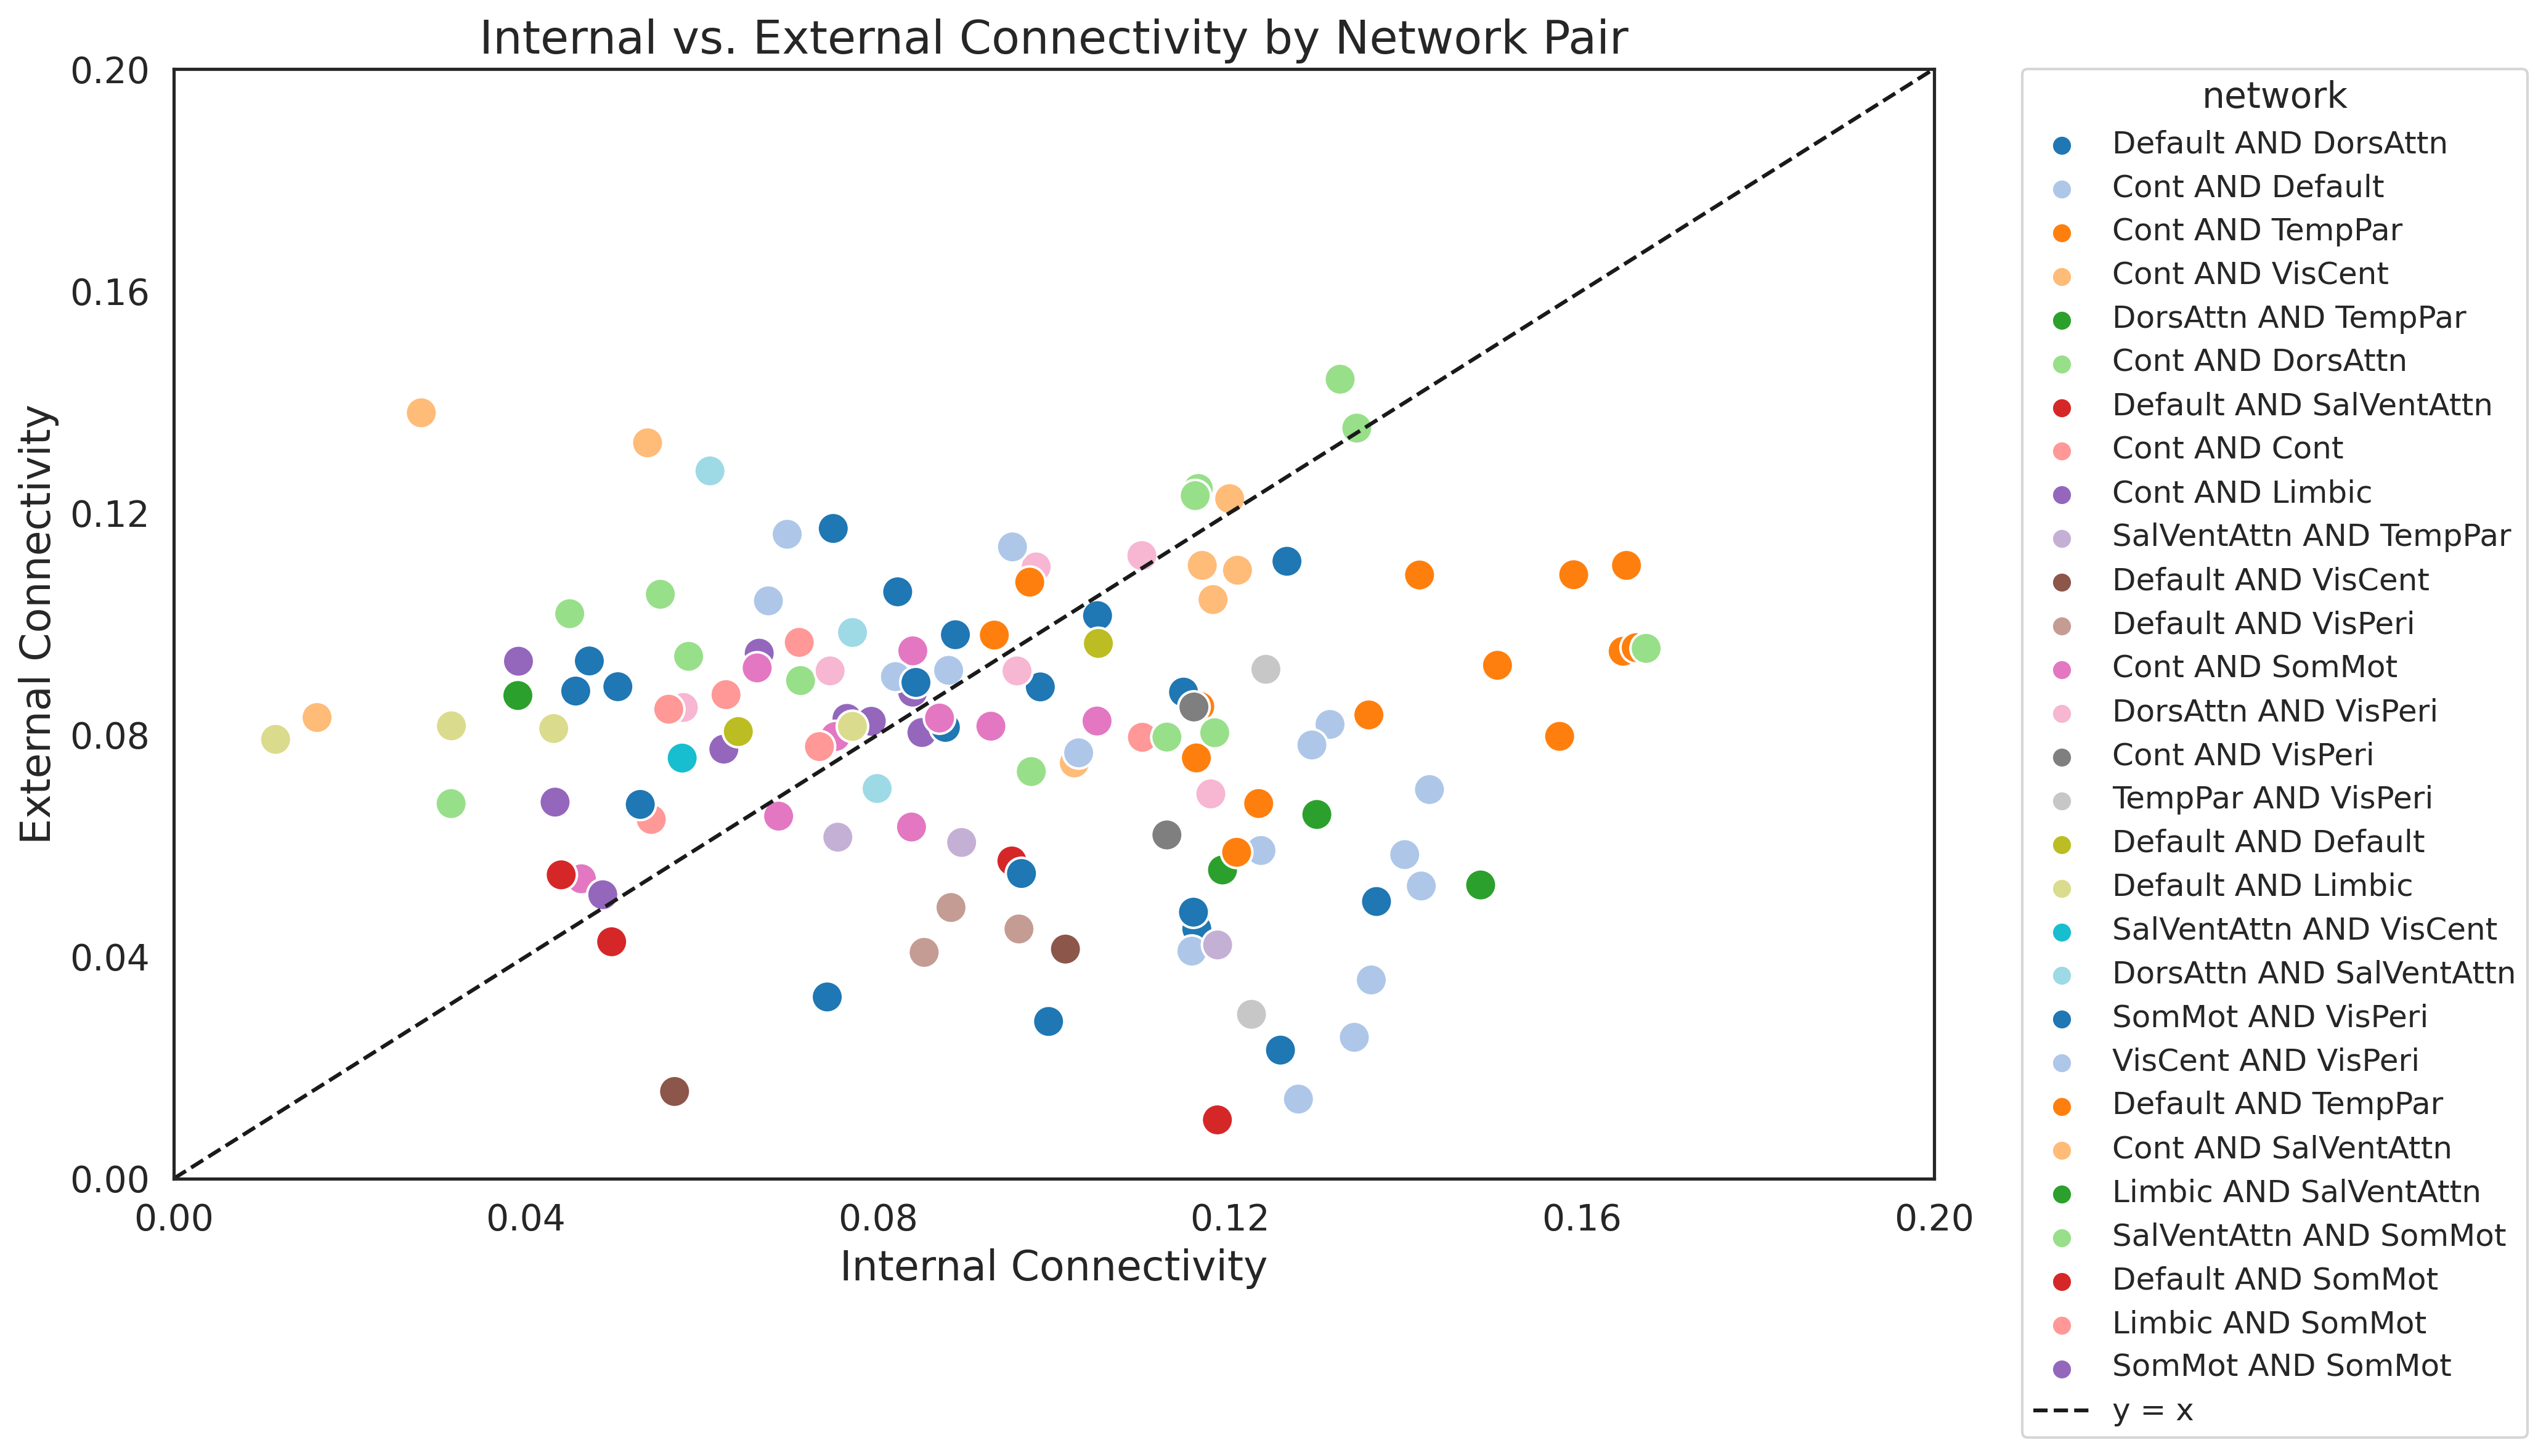

In [166]:
# Create a larger figure
plt.figure(figsize=(14, 8), dpi=300)

# Create scatterplot with larger points
scatter = sns.scatterplot(
    data=df,
    x='internal',
    y='external',
    hue= 'across_hemi_and_type', #'across_hemi_and_type',
    palette='tab20',
    s=150  # Point size increased
)

# Set font sizes
plt.xlabel("Internal Connectivity", fontsize=16)
plt.ylabel("External Connectivity", fontsize=16)
plt.title("Internal vs. External Connectivity by Network Pair", fontsize=18)

# Resize tick labels
scatter.tick_params(axis='both', labelsize=14)

# Calculate the maximum value between the x and y axis
max_value = max(df['internal'].max(), df['external'].max())

# Define limits ensuring both x and y axes share the same max
#lims = [0.0, max_value]
lims = [0.0, .2]

# Set x and y limits to match for identity line
plt.xlim(lims)
plt.ylim(lims)

# Add identity line
plt.plot(lims, lims, 'k--', linewidth=1.5, label='y = x')

# Manually set the ticks for both axes based on the range
step = 0.04  # You can adjust the step size if needed (e.g., 1, 0.5, etc.)
ticks = np.arange(lims[0], lims[1] + step, step)  # Use np.arange for float steps

# Set x and y ticks to match for both axes
plt.gca().set_xticks(ticks)
plt.gca().set_yticks(ticks)

# Resize and move legend
legend = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
legend.set_title("network", prop={'size': 14})
for text in legend.get_texts():
    text.set_fontsize(12)

# Ensure no padding around the plot
plt.tight_layout()

plt.show()


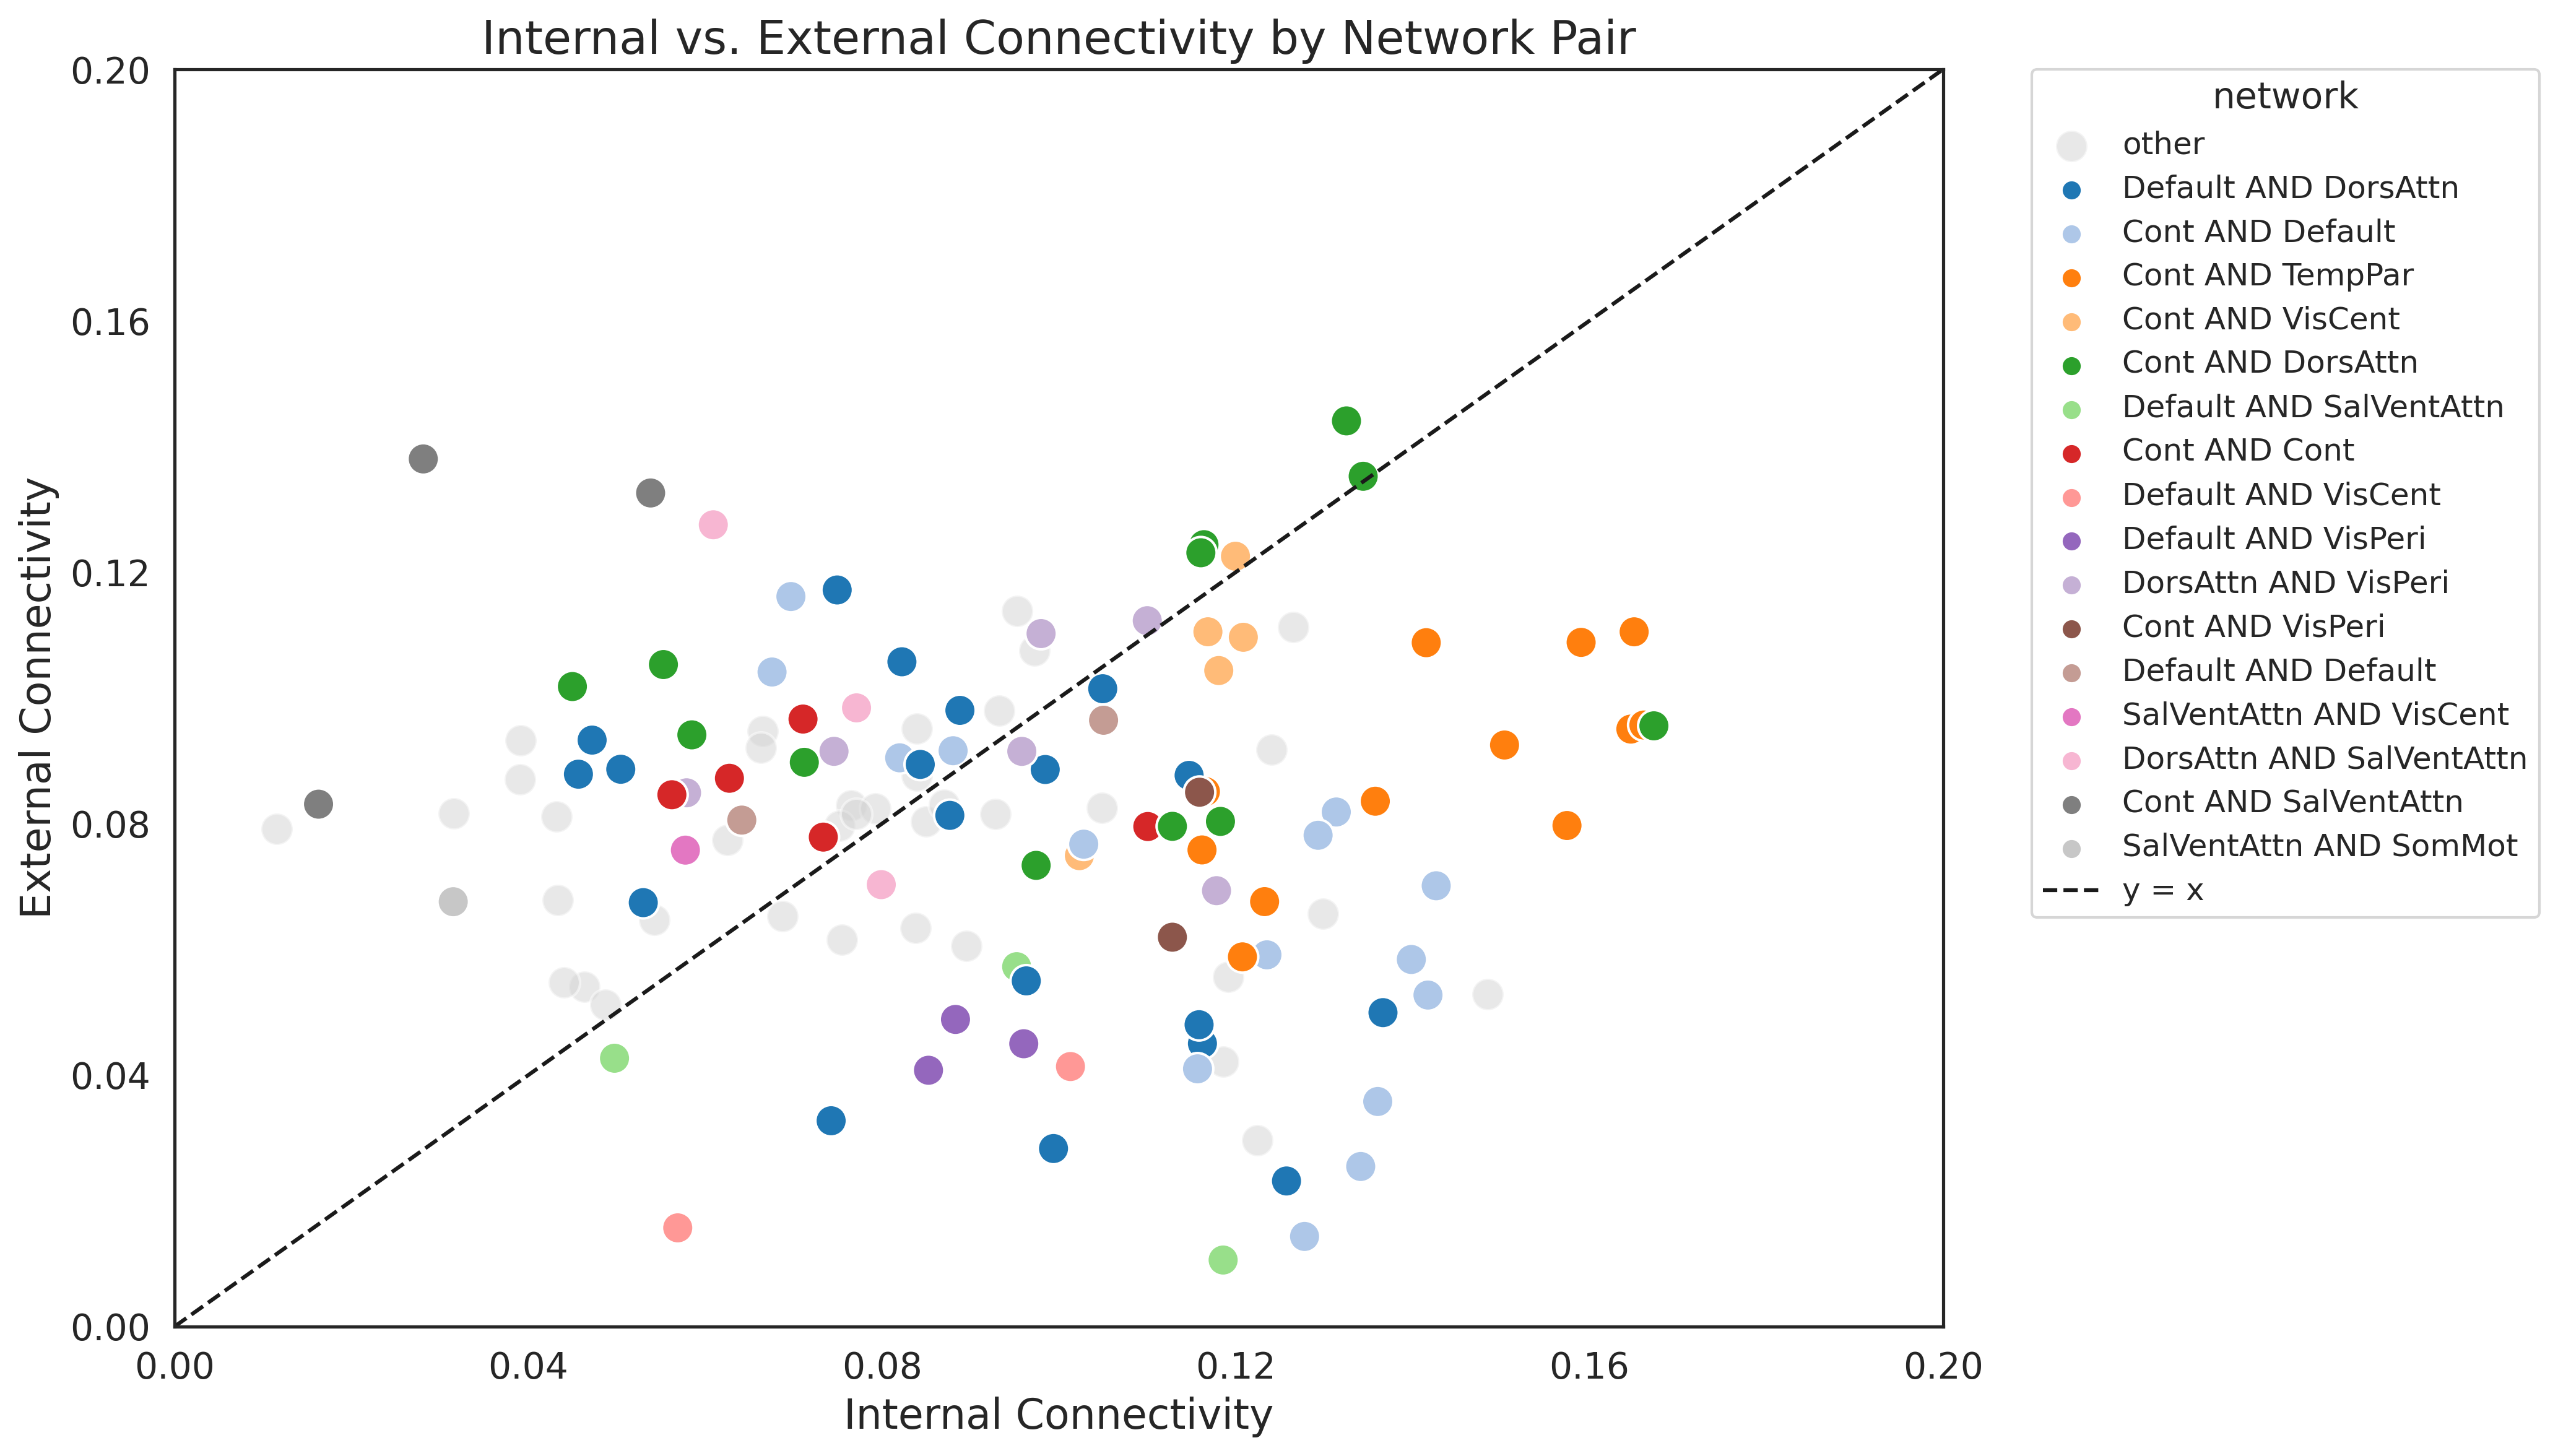

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a larger figure
plt.figure(figsize=(14, 8), dpi=300)

# Split data
df_other = df[df['select_labs'] == 'other']
df_main = df[df['select_labs'] != 'other']

# First: plot 'other' in grey and fully opaque
sns.scatterplot(
    data=df_other,
    x='internal',
    y='external',
    color='lightgray',
    s=150,
    alpha=.5,
    label='other'
)

# Then: plot the rest using a distinct palette
palette = sns.color_palette("tab20", n_colors=df_main['select_labs'].nunique())

sns.scatterplot(
    data=df_main,
    x='internal',
    y='external',
    hue='select_labs',
    palette=palette,
    s=150
)

# Set font sizes
plt.xlabel("Internal Connectivity", fontsize=16)
plt.ylabel("External Connectivity", fontsize=16)
plt.title("Internal vs. External Connectivity by Network Pair", fontsize=18)

# Resize tick labels
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Set x and y limits
lims = [0.0, 0.2]
plt.xlim(lims)
plt.ylim(lims)

# Identity line
plt.plot(lims, lims, 'k--', linewidth=1.5, label='y = x')

# Ticks
step = 0.04
ticks = np.arange(lims[0], lims[1] + step, step)
plt.gca().set_xticks(ticks)
plt.gca().set_yticks(ticks)

# Resize and move legend
legend = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
legend.set_title("network", prop={'size': 14})
for text in legend.get_texts():
    text.set_fontsize(12)

plt.tight_layout()
plt.show()


In [131]:
df['across_hemi_and_type'].unique()

array(['Default AND DorsAttn', 'Cont AND Default', 'Cont AND TempPar',
       'Cont AND VisCent', 'DorsAttn AND TempPar', 'Cont AND DorsAttn',
       'Default AND SalVentAttn', 'Cont AND Cont', 'Cont AND Limbic',
       'SalVentAttn AND TempPar', 'Default AND VisCent',
       'Default AND VisPeri', 'Cont AND SomMot', 'DorsAttn AND VisPeri',
       'Cont AND VisPeri', 'TempPar AND VisPeri', 'Default AND Default',
       'Default AND Limbic', 'SalVentAttn AND VisCent',
       'DorsAttn AND SalVentAttn', 'SomMot AND VisPeri',
       'VisCent AND VisPeri', 'Default AND TempPar',
       'Cont AND SalVentAttn', 'Limbic AND SalVentAttn',
       'SalVentAttn AND SomMot', 'Default AND SomMot',
       'Limbic AND SomMot', 'SomMot AND SomMot'], dtype=object)

In [138]:
# Define the exact network labels you want to keep
networks_to_keep = {
    'L DorsAttnA AND R ContC',
    'L ContC AND R VisCent',
    'L DorsAttnA AND L ContC',
    'R VisCent AND R ContC',
    'L VisCent AND L ContC',
    'L VisCent AND R ContC',
    'R DorsAttnA AND R ContC',
    'L ContC AND R TempPar',
    'L ContC AND R DorsAttnA',
    'L LimbicA AND R ContC',
    'R ContC AND R TempPar',
    'L ContA AND L DefaultA',
    'L DorsAttnA AND L DefaultA',
    'L ContA AND L ContC',
    'L LimbicA AND L ContC'
}

# Create a new column 'focused_network' based on that filter
df['focused_network'] = df['network'].apply(
    lambda x: x if x in networks_to_keep else 'other'
)




In [168]:
# Define the set of labels you want to keep
labels_to_keep = {
    'Default AND DorsAttn', 'Cont AND Default', 'Cont AND TempPar',
    'Cont AND VisCent', 'Cont AND DorsAttn', 'Default AND SalVentAttn',
    'Cont AND Cont', 'Default AND VisCent', 'Default AND VisPeri',
    'DorsAttn AND VisPeri', 'Cont AND VisPeri', 'Default AND Default',
    'SalVentAttn AND VisCent', 'DorsAttn AND SalVentAttn',
    'Cont AND SalVentAttn', 'SalVentAttn AND SomMot'
}

# Create the new column
df['select_labs'] = df['across_hemi_and_type'].apply(
    lambda x: x if x in labels_to_keep else 'other'
)

In [169]:
df

,network,external,internal,across_hemi,across_hemi_and_type,select_labs
0,L DefaultB AND R DorsAttnA,0.045011,0.116235,DefaultB AND DorsAttnA,Default AND DorsAttn,Default AND DorsAttn
1,L DefaultB AND R ContA,0.059124,0.123528,ContA AND DefaultB,Cont AND Default,Cont AND Default
2,L ContC AND R TempPar,0.095038,0.164686,ContC AND TempPar,Cont AND TempPar,Cont AND TempPar
3,R ContB AND R TempPar,0.075812,0.116187,ContB AND TempPar,Cont AND TempPar,Cont AND TempPar
4,R ContC AND R TempPar,0.095685,0.166160,ContC AND TempPar,Cont AND TempPar,Cont AND TempPar
...,...,...,...,...,...,...
126,L SomMotA AND R LimbicA,0.064724,0.054249,LimbicA AND SomMotA,Limbic AND SomMot,other
127,L SomMotA AND R SomMotB,0.093242,0.039162,SomMotA AND SomMotB,SomMot AND SomMot,other
128,L DefaultA AND R ContA,0.091593,0.088038,ContA AND DefaultA,Cont AND Default,Cont AND Default
129,L DefaultC AND R DorsAttnB,0.067431,0.052998,DefaultC AND DorsAttnB,Default AND DorsAttn,Default AND DorsAttn


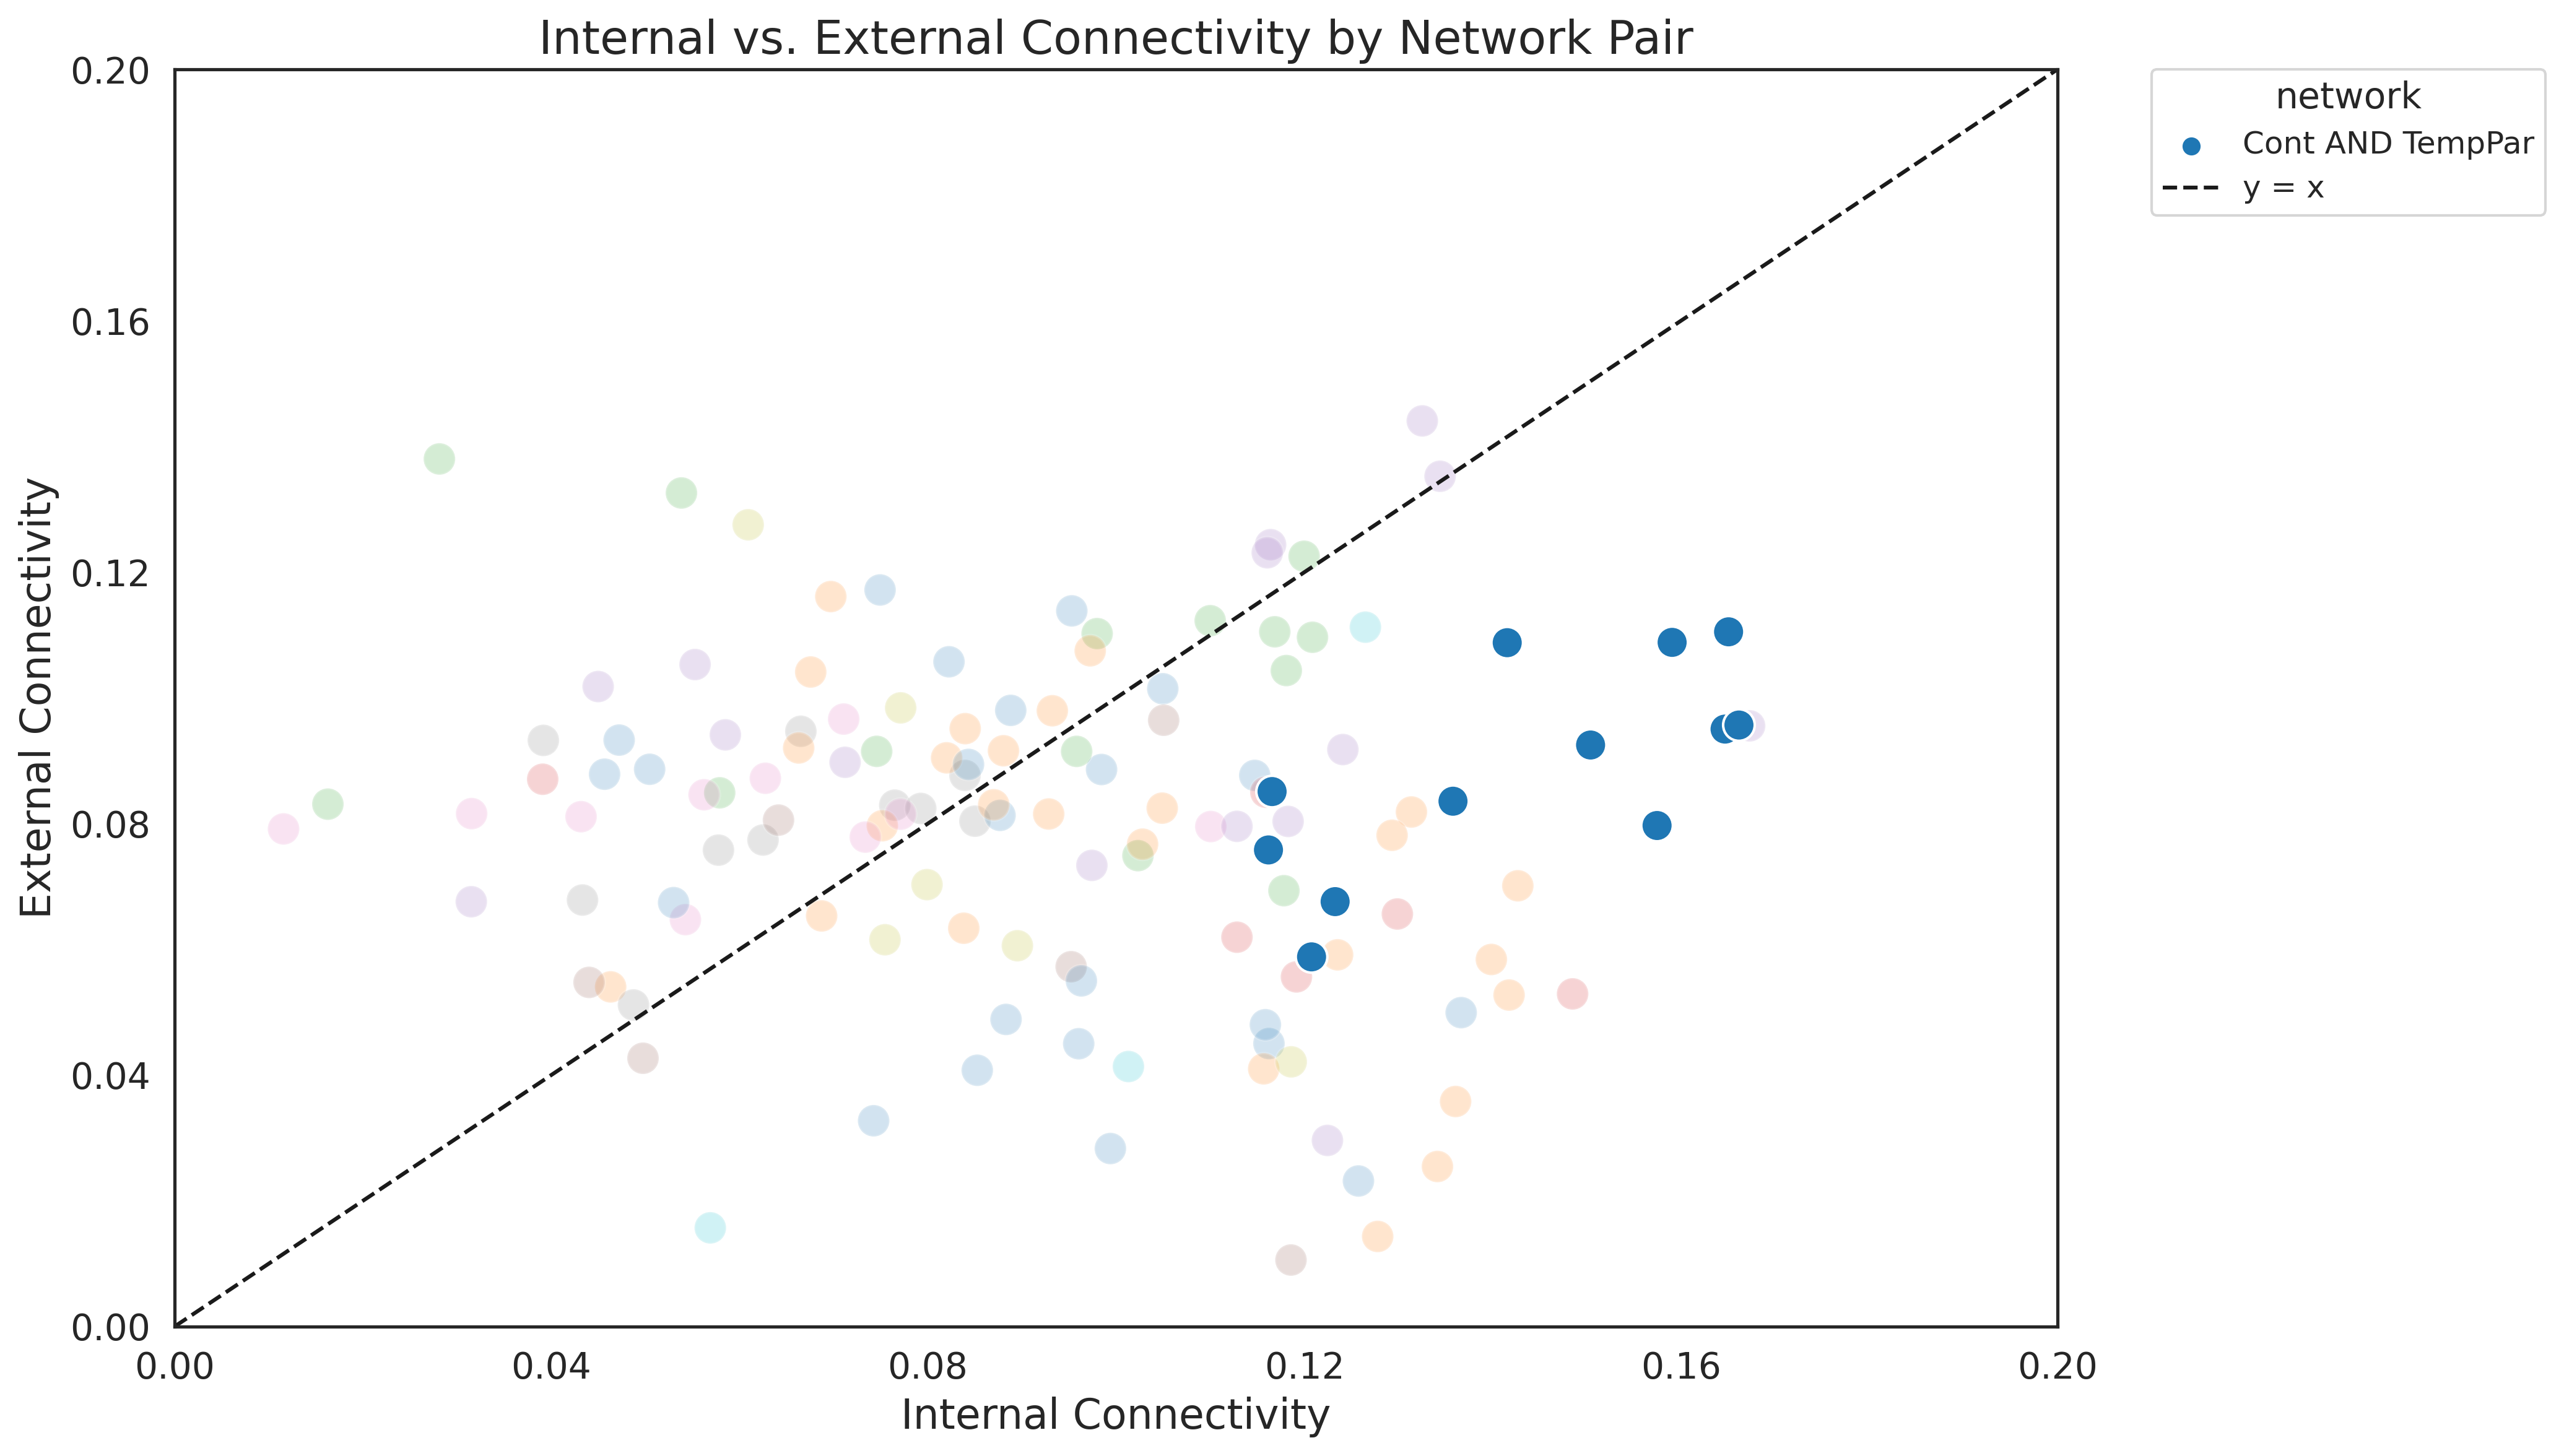

In [142]:
# Choose the label you want to highlight (e.g., "Visual AND DMN")
# 'Cont AND Default' Cont AND SalVentAttn
highlight_label = 'Cont AND TempPar'#'Cont AND DorsAttn'  # <-- Replace this with the label you want fully opaque

# Split the data
df_highlight = df[df['across_hemi_and_type'] == highlight_label]
df_faded = df[df['across_hemi_and_type'] != highlight_label]

# Create figure
plt.figure(figsize=(14, 8), dpi=300)

# Plot faded (low alpha) points first
sns.scatterplot(
    data=df_faded,
    x='internal',
    y='external',
    hue='across_hemi_and_type',
    palette='tab10',
    s=150,
    alpha=0.2,
    legend=False  # suppress to avoid duplicates
)

# Plot highlighted (full alpha) points
sns.scatterplot(
    data=df_highlight,
    x='internal',
    y='external',
    hue='across_hemi_and_type',
    palette='tab10',
    s=150,
    alpha=1.0
)

# Labels and title
plt.xlabel("Internal Connectivity", fontsize=16)
plt.ylabel("External Connectivity", fontsize=16)
plt.title("Internal vs. External Connectivity by Network Pair", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Limits and identity line
lims = [0.0, 0.2]
plt.xlim(lims)
plt.ylim(lims)
plt.plot(lims, lims, 'k--', linewidth=1.5, label='y = x')

# Custom ticks
step = 0.04
ticks = np.arange(lims[0], lims[1] + step, step)
plt.xticks(ticks)
plt.yticks(ticks)

# Adjust legend
legend = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
legend.set_title("network", prop={'size': 14})
for text in legend.get_texts():
    text.set_fontsize(12)

plt.tight_layout()
plt.show()
